In [66]:
import jax
import flax.linen as nn
import optax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from flax.training.train_state import TrainState

from jax_dataloader import DataLoader, ArrayDataset
import jax_dataloader as jdl
from typing import List, Callable
from collections import defaultdict
from functools import partial

jdl.manual_seed(141232)

In [67]:
class MLP(nn.Module):
    hidden_layers: List[int]  # List of integers specifying the number of neurons in each hidden layer
    output_dim: int      # Number of output neurons
    activation: Callable = nn.gelu  # Activation function (default is GELU)

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for units in self.hidden_layers:
            x = nn.Dense(units)(x)
            x = self.activation(x)
        x = nn.Dense(self.output_dim,use_bias=False)(x)  # Output layer
        return x

In [100]:
@partial(jax.jit,static_argnames=['k','tol'])
def pinv(M: jnp.ndarray, key, k: int, tol:float=1e-10) -> jnp.ndarray:
    U, S, Vh = randomized_SVD(M, k=k, key=key)
    S_inv = jnp.where(S > tol, 1.0 / S, 0.0)
    result = Vh.T @ jnp.diag(S_inv) @ U.T
    return result

@partial(jax.jit,static_argnames=['k'])
def randomized_SVD(A:jnp.ndarray, k:int, key, p:int=10, q:int=0, rtol:float=1e-3):
    m,n = A.shape
    r = k+p

    Omega = jax.random.normal(key, (n, r))
    Y = A @ Omega
    for _ in range(q):
        Y = A @ (A.T @ Y)
    Q,_ = jnp.linalg.qr(Y)
    B = Q.T @ A
    Ub,S,Vh = jnp.linalg.svd(B, full_matrices=False)
    U = Q @ Ub

    U = U[:,:k]
    S = S[:k]
    Vh = Vh[:k,:]
    S = jnp.where(S > rtol * S[0], S, 0)
    return U, S, Vh

# Define dataset

In [101]:
train_key, test_key, val_key = jax.random.split(jax.random.key(124893), 3)
xtrain = jax.random.uniform(train_key, (10_000,1),minval=-1.0,maxval=1.0)
xval = jax.random.uniform(val_key, (10_000,1),minval=-1.0,maxval=1.0)
xtest = jnp.linspace(-1.0,1.0,10_000).reshape(-1,1)

def f(x):
    return jnp.exp(-10*x**2)*jnp.sin(2*x)

ytrain = f(xtrain)
yval = f(xval)
ytest = f(xtest)

train_dataset = ArrayDataset(xtrain,ytrain)
val_dataset = ArrayDataset(xval,yval)
test_dataset = ArrayDataset(xtest,ytest)

# Direct regression

In [95]:
model = MLP(hidden_layers=[16,16],output_dim=1)
init_key = jax.random.key(4239589)
params_mse = model.init(init_key,jnp.ones((1,1)))['params']

learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params_mse)

@jax.jit
def loss_fn(params,batch):
    x,y = batch
    ypred = model.apply({'params':params},x)
    loss = jnp.mean((ypred-y)**2)
    return loss

@jax.jit
def train_step_mse(params,batch,opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss 

@jax.jit
def val_step(params,batch):
    loss = loss_fn(params,batch)
    return loss

train_loader = DataLoader(train_dataset,batch_size=1024,shuffle=True,backend='jax')
val_loader = DataLoader(val_dataset,batch_size=10_000,shuffle=False,backend='jax')

num_epoch = 500
losses_mse = defaultdict(list)
key = jax.random.key(2578924)

for epoch in tqdm(range(num_epoch)):
    epoch_losses = defaultdict(list)
    for batch in train_loader:
        key, svd_key = jax.random.split(key)
        params_mse, opt_state, loss = train_step_mse(params_mse,batch,opt_state)
        epoch_losses['train'].append(loss)
    for batch in val_loader:
        loss = val_step(params_mse,batch)
        epoch_losses['val'].append(loss)
    for k,v in epoch_losses.items():
        losses_mse[k].append(np.mean(v))

100%|██████████| 500/500 [00:16<00:00, 30.12it/s]


# SVD SGD

In [103]:
model = MLP(hidden_layers=[16,16],output_dim=1)
init_key = jax.random.key(4239589)
params_svd = model.init(init_key,jnp.ones((1,1)))['params']

@partial(jax.jit, static_argnames=['k'])
def train_step_svd_sgd(params,batch,k,lr,key):
    pvec, ravel_fn = jax.flatten_util.ravel_pytree(params)
    x,y = batch
    def apply_fn(p):
        return model.apply({'params':ravel_fn(p)},x).flatten() # assuming 1D output
    J = jax.jacrev(apply_fn)(pvec) # B x N_params
    ypred = model.apply({'params':params},x)
    b = (ypred - y).flatten() # B
    pseudo_inv = pinv(J,key=key,k=k) # N_params x B
    delta_p = pseudo_inv @ b
    loss = jnp.mean((ypred-y)**2)
    pvec = pvec - lr*delta_p
    return ravel_fn(pvec), loss

@jax.jit
def val_step(params,batch):
    x,y = batch
    ypred = model.apply({'params':params},x)
    loss = jnp.mean((ypred-y)**2)
    return loss

train_loader = DataLoader(train_dataset,batch_size=80,shuffle=True,backend='jax')
val_loader = DataLoader(val_dataset,batch_size=10_000,shuffle=False,backend='jax')

lr = 1.0
k_svd=5

num_epoch = 500
losses_svd = defaultdict(list)
key = jax.random.key(2578924)

for epoch in tqdm(range(num_epoch)):
    epoch_losses = defaultdict(list)
    for batch in train_loader:
        key, svd_key = jax.random.split(key)
        params_svd, loss = train_step_svd_sgd(params_svd,batch,k=k_svd,lr=lr,key=svd_key)
        epoch_losses['train'].append(loss)
    for batch in val_loader:
        loss = val_step(params_svd,batch)
        epoch_losses['val'].append(loss)
    for k,v in epoch_losses.items():
        losses_svd[k].append(np.mean(v))

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [03:47<00:00,  2.20it/s]


# Compare

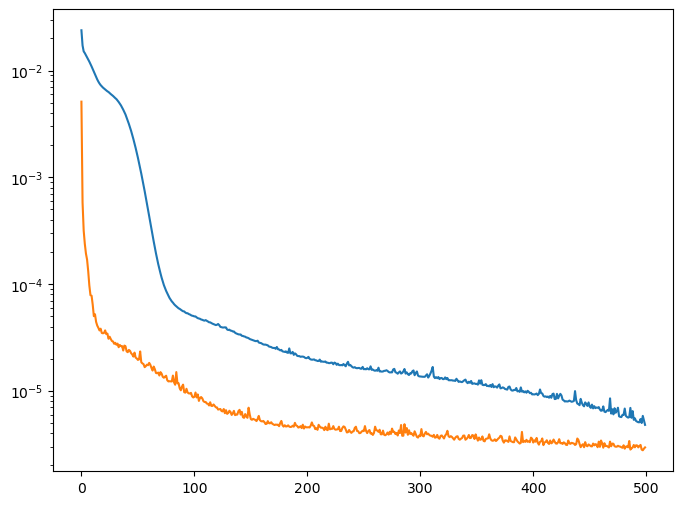

In [104]:
plt.figure(figsize=(8,6))
plt.plot(losses_mse['val'],label='MSE')
plt.plot(losses_svd['val'],label='SVD')
plt.yscale('log')